In [1]:
pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 10.6 MB/s eta 0:00:00


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tensorflow
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.svm import SVC

import phik
from phik.report import plot_correlation_matrix

In [3]:
pip install ucimlrepo

#1 - Chargement du Dataset

In [18]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
parkinsons = fetch_ucirepo(id=174)

# data (as pandas dataframes)
X = parkinsons.data.features
y = parkinsons.data.targets

# metadata
print(parkinsons.metadata)

# variable information
print(parkinsons.variables)


{'uci_id': 174, 'name': 'Parkinsons', 'repository_url': 'https://archive.ics.uci.edu/dataset/174/parkinsons', 'data_url': 'https://archive.ics.uci.edu/static/public/174/data.csv', 'abstract': "Oxford Parkinson's Disease Detection Dataset", 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 197, 'num_features': 22, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['status'], 'index_col': ['name'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2007, 'last_updated': 'Wed Feb 14 2024', 'dataset_doi': '10.24432/C59C74', 'creators': ['Max Little'], 'intro_paper': {'ID': 385, 'type': 'NATIVE', 'title': 'Exploiting Nonlinear Recurrence and Fractal Scaling Properties for Voice Disorder Detection', 'authors': 'Max A. Little, P. McSharry, S. Roberts, D. Costello, I. Moroz', 'venue': 'BioMedical Engineering OnLine', 'year': 2007, 'journal': None, 'DOI': '10.1186/1475-925X-6-23', 'URL

2 - Etudions la distribution des classes

In [ ]:
print("Distribution des classes :")
print(y['status'].value_counts())

Distribution des classes :
status
1    147
0     48
Name: count, dtype: int64


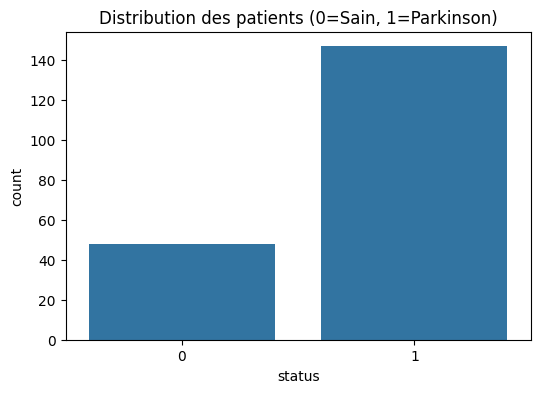

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y['status'])
plt.title('Distribution des patients (0=Sain, 1=Parkinson)')
plt.show()

3 - Corrélation entre les variables

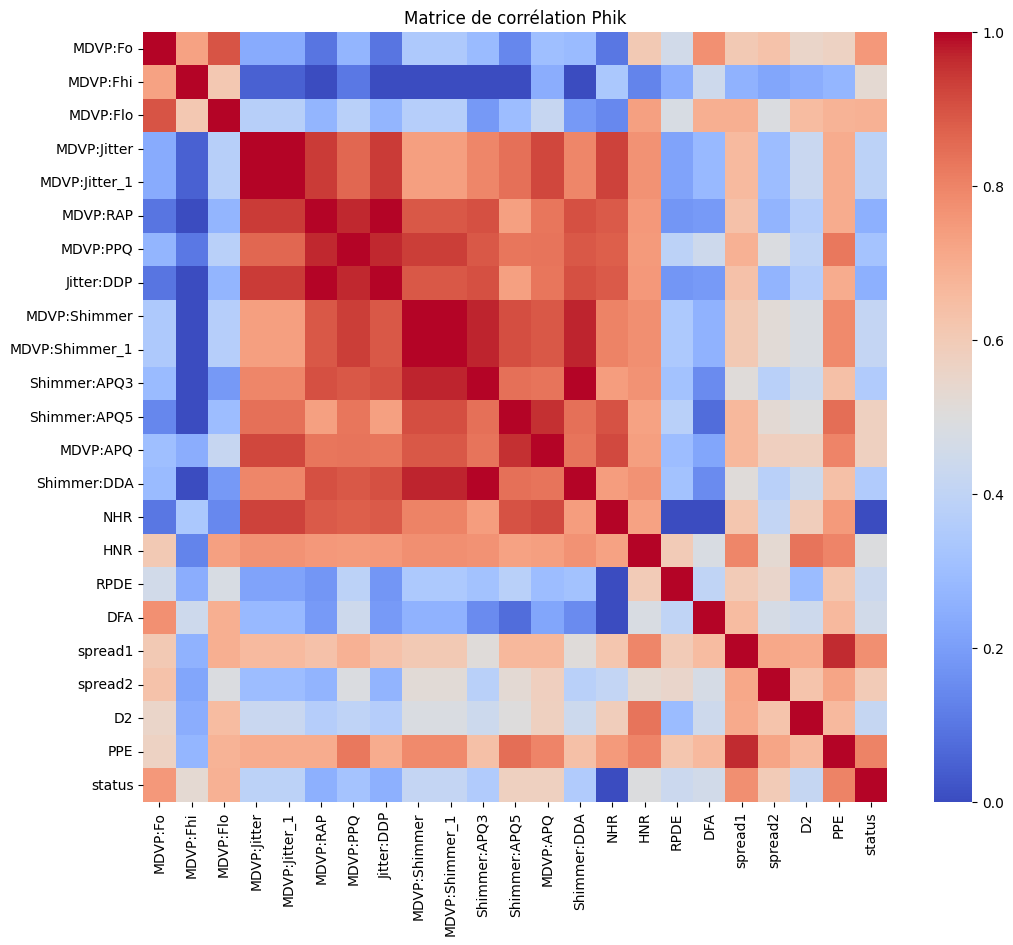

In [14]:
def make_columns_unique(df):
    cols = pd.Series(df.columns)
    for dup in cols[cols.duplicated()].unique():
        current_dup_indices = cols[cols == dup].index.values.tolist()
        for i, idx in enumerate(current_dup_indices):
            cols[idx] = f"{dup}_{i}" if i > 0 else dup
    df.columns = cols
    return df

X_unique_cols = make_columns_unique(X.copy())

df_full = pd.concat([X_unique_cols, y], axis=1)

interval_cols = df_full.columns.drop('status').tolist()

# Calcul de la matrice des corrélations phik
phik_matrix = df_full.phik_matrix(interval_cols=interval_cols)

# Affichage
plt.figure(figsize=(12, 10))
sns.heatmap(phik_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title('Matrice de corrélation Phik')
plt.show()

4 - PCA : Scaling & PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

#Initialiser le scaler
scaler_global = StandardScaler()

#Normaliser le dataset
# On utilise fit_transform pour calculer la moyenne/écart-type et transformer les données
X_scaled_array = scaler_global.fit_transform(X)


X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

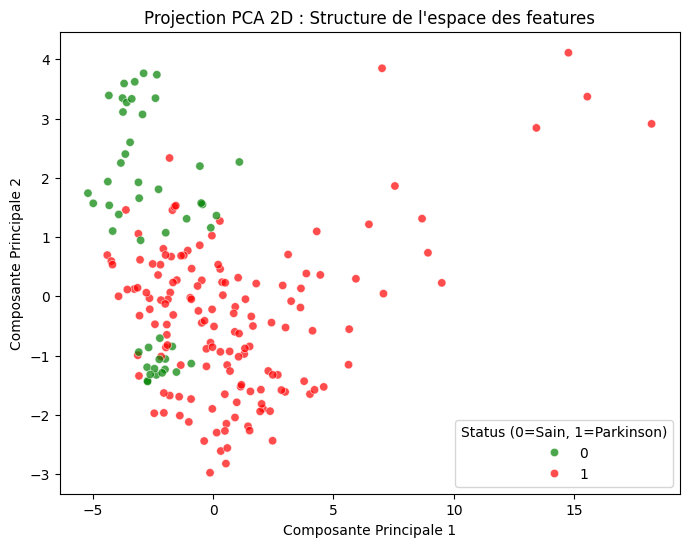

Variance expliquée par les 2 composantes : 70.56%


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y['status'], palette={0: 'green', 1: 'red'}, alpha=0.7)
plt.title('Projection PCA 2D : Structure de l\'espace des features')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.legend(title='Status (0=Sain, 1=Parkinson)')
plt.show()
print(f"Variance expliquée par les 2 composantes : {sum(pca.explained_variance_ratio_):.2%}")

#3 - Entrainement de l'AutoEncoder

In [22]:
# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

#Normalisation (StandardScaler)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Taille des données d'entraînement : {X_train_scaled.shape}")
print(f"Taille des données de test : {X_test_scaled.shape}")

Taille des données d'entraînement : (156, 22)
Taille des données de test : (39, 22)


1. Préparation des données spécifique à l'AutoEncoder

In [ ]:
# On prend les index où status == 0 dans y_train
X_train_healthy = X_train_scaled[y_train['status'] == 0]

# On utilisera aussi une petite partie des sains pour valider pendant l'entraînement
print(f"Nombre d'échantillons sains pour l'entraînement : {X_train_healthy.shape[0]}")

Nombre d'échantillons sains pour l'entraînement : 38


2. Architecture du Modèle (Keras)

In [27]:
input_dim = X_train_scaled.shape[1]

# Construction du modèle
autoencoder = Sequential([
    # --- Encoder ---
    Dense(14, activation='tanh', input_shape=(input_dim,)),
    Dense(8, activation='relu'), # Espace latent (représentation compressée)

    # --- Decoder ---
    Dense(14, activation='tanh'),
    Dense(input_dim, activation='linear') #
])

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 14)             │           322 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 8)              │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 14)             │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 22)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 898 (3.51 KB)

 Trainable params: 898 (3.51 KB)

 Non-trainable params: 0 (0.00 B)

3. Entraînement

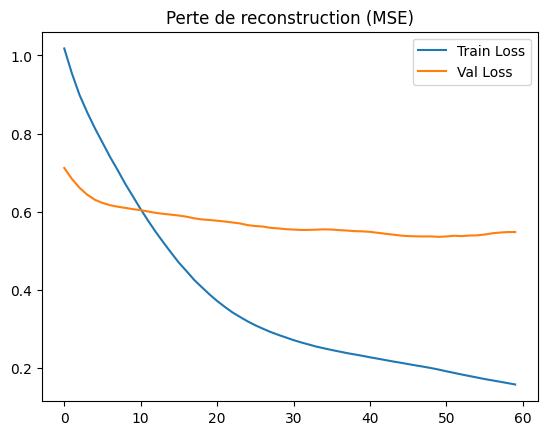

In [28]:
# Callback pour arrêter si le modèle n'apprend plus (évite l'overfitting)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraînement sur les données SAINES uniquement
history = autoencoder.fit(
    X_train_healthy, X_train_healthy,
    epochs=100,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# Visualisation de la perte
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perte de reconstruction (MSE)')
plt.legend()
plt.show()

4. Évaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


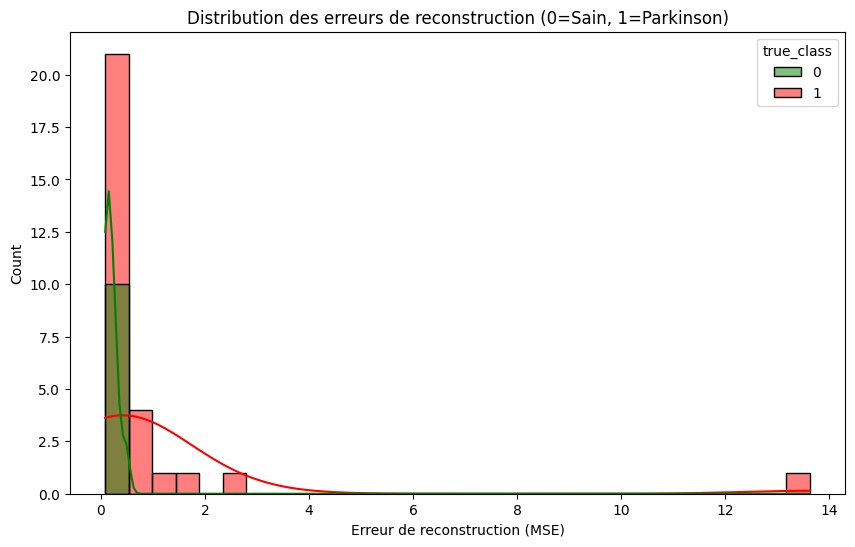

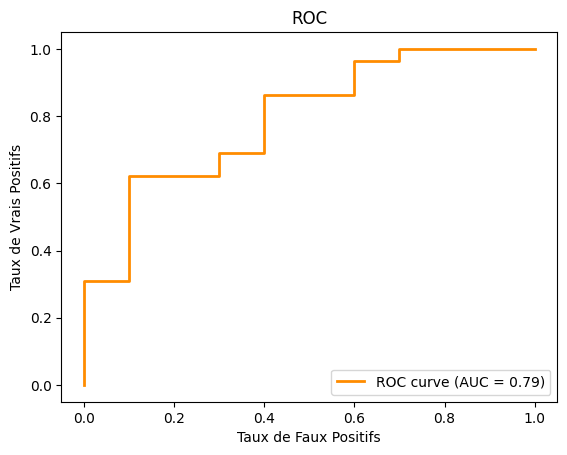

Seuil optimal de séparation (MSE) : 0.2935

Résultats AUTOENCODER
              precision    recall  f1-score   support

           0       0.43      0.90      0.58        10
           1       0.94      0.59      0.72        29

    accuracy                           0.67        39
   macro avg       0.69      0.74      0.65        39
weighted avg       0.81      0.67      0.69        39



In [29]:
from sklearn.metrics import roc_curve, auc, classification_report, accuracy_score

#Calculer les reconstructions sur le jeu de test
reconstructions = autoencoder.predict(X_test_scaled)

# Calculer l'erreur (MSE) pour chaque patient individuellement
mse_per_sample = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

results_df = pd.DataFrame({'mse': mse_per_sample, 'true_class': y_test['status']})

plt.figure(figsize=(10, 6))
sns.histplot(data=results_df, x='mse', hue='true_class', bins=30, kde=True, palette={0: 'green', 1: 'red'})
plt.title('Distribution des erreurs de reconstruction (0=Sain, 1=Parkinson)')
plt.xlabel('Erreur de reconstruction (MSE)')
plt.show()

#Analyse ROC
fpr, tpr, thresholds = roc_curve(y_test, mse_per_sample)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('ROC')
plt.legend(loc="lower right")
plt.show()

# Classification finale
# On choisit un seuil optimal (souvent celui qui maximise J = TPR - FPR, ou un seuil manuel d'après l'histogramme)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Seuil optimal de séparation (MSE) : {optimal_threshold:.4f}")

# Générer les prédictions 0 ou 1 basées sur ce seuil
y_pred_dl = (mse_per_sample > optimal_threshold).astype(int)

print("\nRésultats AUTOENCODER")
print(classification_report(y_test, y_pred_dl))

#4 - Entrainement du SVM

In [23]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

In [24]:
svm_model.fit(X_train_scaled, y_train['status'].values.ravel())

SVC(random_state=42)

In [25]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [26]:
print(classification_report(y_test['status'], y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        10
           1       0.85      1.00      0.92        29

    accuracy                           0.87        39
   macro avg       0.93      0.75      0.79        39
weighted avg       0.89      0.87      0.86        39

